# **Fase 1: Planteamiento del problema**

## **1.1  Contexto y justificación**

**Effects of Alcohol on Student Performance**

datset tmado de kaggle https://www.kaggle.com/datasets/joshuanaude/effects-of-alcohol-on-student-performance


**Varibales originales**

En el dataset encontramos 17 variables

1. **Timestamp**: Marca temporal

2. **Your Sex?**: ¿Tu sexo?

3. **Your Matric (grade 12) Average/ GPA (in %)**: Tu promedio de preparatoria/bachillerato (grado 12) en %

4. **What year were you in last year (2023)?**: ¿En qué año estuviste el año pasado (2023)?

5. **What faculty does your degree fall under?**: ¿A qué facultad pertenece tu carrera?

6.**Your 2023 academic year average/GPA in % (Ignore if you are 2024 1st year student)**: Tu promedio académico de 2023 en % (Ignorar si eres estudiante de primer año en 2024)

7. **Your Accommodation Status Last Year (2023)**: Tu situación de alojamiento el año pasado (2023)

8. **Monthly Allowance in 2023**: Mesada o presupuesto mensual en 2023

9. **Were you on scholarship/bursary in 2023?**: ¿Tuviste alguna beca o subsidio en 2023?

10. **Additional amount of studying (in hrs) per week**: Horas adicionales de estudio por semana

11. **How often do you go out partying/socialising during the week?**: ¿Con qué
frecuencia sales de fiesta o socializas durante la semana?

12. **On a night out, how many alcoholic drinks do you consume?**: En una noche de fiesta, ¿cuántas bebidas alcohólicas consumes?

13. **How many classes do you miss per week due to alcohol reasons, (i.e: being hungover or too tired?)**: ¿Cuántas clases pierdes a la semana por motivos relacionados con el alcohol (ej: resaca o cansancio excesivo)?

14. **How many modules have you failed thus far into your studies?**: ¿Cuántas materias/módulos has reprobado en lo que va de tus estudios?

15. **Are you currently in a romantic relationship?**: ¿Tienes una relación sentimental actualmente?

16. **Do your parents approve alcohol consumption?**: ¿Tus padres aprueban el consumo de alcohol?

17. **How strong is your relationship with your parent/s**?: ¿Qué tan fuerte es la relación con tu(s) padre(s)?


## **1.2 Objetivos**

- **Objetivo general**
  
    Determinar si existe asociación significativa entre el consumo de alcohol y el rendimiento académico.

- **Objetivos específicos**
  
   * Comparar GPA por nivel de consumo
   * identificar variables confusoras
   *  cuantificar efectos

## **1.3 Pregunta de investigación**

- ¿Existe asociación estadísticamente significativa entre el consumo de alcohol y el rendimiento académico universitario, controlando por variables socioeconómicas y de hábitos de estudio?

Otras preguntas de interés

- ¿El efecto difiere por género?
- ¿Las horas de estudio moderan el efecto del alcohol?

## **1.4 Alcance y limitaciones**

- Estudio basado en encuesta
- sesgo de una sola universidad

# **Fase 2: EDA Univariado**

## **2.1 Carga y limpieza**

In [74]:
# Cargamos las librerias becesarias para la exloración

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


import warnings
warnings.filterwarnings("ignore")

In [75]:
# =========================
# CONFIGURACIÓN SEABORN
# =========================
sns.set_theme(
    context="notebook",      # paper, notebook, talk, poster
    style="whitegrid",       # white, dark, whitegrid, darkgrid, ticks
    palette="deep",          # deep, muted, bright, pastel, dark, colorblind
    font="serif",
    font_scale=1.2
)


In [76]:
# establecemos la ruta del dataset (.csv) en Drive
from google.colab import drive
drive.mount("/content/drive")

ruta = "/content/drive/MyDrive/MAESTRIA_CIENCIA_DE_DATOS/data-sets/raw_data/Alcohol-on-Student -Performance.csv"

df = pd.read_csv(ruta)
df

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,Timestamp,Your Sex?,Your Matric (grade 12) Average/ GPA (in %),What year were you in last year (2023) ?,What faculty does your degree fall under?,Your 2023 academic year average/GPA in % (Ignore if you are 2024 1st year student),Your Accommodation Status Last Year (2023),Monthly Allowance in 2023,Were you on scholarship/bursary in 2023?,Additional amount of studying (in hrs) per week,How often do you go out partying/socialising during the week?,"On a night out, how many alcoholic drinks do you consume?","How many classes do you miss per week due to alcohol reasons, (i.e: being hungover or too tired?)",How many modules have you failed thus far into your studies?,Are you currently in a romantic relationship?,Do your parents approve alcohol consumption?,How strong is your relationship with your parent/s?
0,2024/03/07 5:12:01 pm EET,Female,76.0,2nd Year,Arts & Social Sciences,72.0,Private accommodation/ stay with family/friends,R 4001- R 5000,No,8+,Only weekends,8+,3,0,Yes,Yes,Very close
1,2024/03/07 5:12:08 pm EET,Male,89.0,2nd Year,Economic & Management Sciences,75.0,Private accommodation/ stay with family/friends,R 7001 - R 8000,"Yes (NSFAS, etc...)",8+,Only weekends,3-5,4+,0,No,Yes,Very close
2,2024/03/07 5:12:25 pm EET,Male,76.0,1st Year,AgriSciences,55.0,Private accommodation/ stay with family/friends,R 4001- R 5000,No,3-5,2,8+,3,0,No,Yes,Very close
3,2024/03/07 5:12:28 pm EET,Male,89.0,2nd Year,Engineering,84.0,Private accommodation/ stay with family/friends,R 6001 - R 7000,No,3-5,3,8+,2,0,Yes,Yes,Very close
4,2024/03/07 5:13:00 pm EET,Female,74.0,2nd Year,Arts & Social Sciences,52.0,Private accommodation/ stay with family/friends,R 4001- R 5000,No,3-5,Only weekends,5-8,1,3,No,Yes,Fair
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
401,2024/03/12 11:05:33 am EET,Female,74.0,NaN,Science,NaN,Private accommodation/ stay with family/friends,NaN,No,3-5,3,1-3,0,0,No,Yes,Close
402,2024/03/12 3:26:14 pm EET,Female,73.0,2nd Year,Economic & Management Sciences,58.0,Private accommodation/ stay with family/friends,R 6001 - R 7000,"Yes (NSFAS, etc...)",5-8,1,8+,0,0,Yes,Yes,Very close
403,2024/03/13 10:32:19 pm EET,Female,86.0,1st Year,NaN,NaN,Private accommodation/ stay with family/friends,R 4001- R 5000,No,5-8,2,3-5,1,0,No,Yes,Very close
404,2024/03/13 10:32:27 pm EET,Male,85.0,NaN,Economic & Management Sciences,NaN,Private accommodation/ stay with family/friends,R 4001- R 5000,No,1-3,4+,5-8,4+,0,No,Yes,Close


**Vamos a obtener información general del datset**


In [77]:
# dimensión del datset
filas, cols = df.shape
print(f"El datset tien {filas} filas y {cols} columas")

El datset tien 406 filas y 17 columas


**Tipo de variable**

Verifiquemios el tipo de cada una de las variables

In [78]:
# Veams el tipo de variables
df.dtypes

,0
Timestamp,object
Your Sex?,object
Your Matric (grade 12) Average/ GPA (in %),float64
What year were you in last year (2023) ?,object
What faculty does your degree fall under?,object
Your 2023 academic year average/GPA in % (Ignore if you are 2024 1st year student),float64
Your Accommodation Status Last Year (2023),object
Monthly Allowance in 2023,object
Were you on scholarship/bursary in 2023?,object
Additional amount of studying (in hrs) per week,object


Se puede observar:

 - Nombres de las variables son extensos ya que  corresponde a preguntas de caracter personal (excepto **Timestamp**), se suguiere cambiara nobre de variables a nombres representativos para obtener mejores resultados como pior ejemplo al momento de vizualiza.

 - Se debe prestar especial atención en las variables cuyo tipo de dato es ambiguo o confuso, para darle el tratamiento adecuando, como por ejemplo:
   * **Monthly Allowance in 2023**,
   * **additional amount of studying (in hrs) per week**,
   * **How often do you go out partying/socialising during the week?**,
   * **n a night out, how many alcoholic drinks do you consume?**,
   * **ow many classes do you miss per week due to alcohol reasons, (i.e: being hungover or too tired?**,
   * **ow many modules have you failed thus far into your studies?**
   
  algunas de estas variables podrían ser de tipo entero.

- La variable **Timestamp** debe ser convertida a tipo fecha

Lo primero quwe haremos es cambiar los nombres d ela variables


In [79]:
nombre_variables_originales = df.columns.tolist()
nombres_nuevos = ["fecha", "genero", "promedio_escuela", "año_anterior", "facultad", "promedio_año_anterior",
                  "alojamiento_2023", "presupuesto", "beca", "horas_estudio_semanal", "fiestas_semanales",
                  "consumo_bebidas_alcoholicas", "clases_perdidas(alcohol)", "reprobaciones", "relacion_sentimental", "aprobacion_padres_alcohol",
                  "tipo_relacion(padres)"]

def reemplazar_nombre_variable():
  for i in range(len(nombre_variables_originales)):
    df.rename(columns={nombre_variables_originales[i]: nombres_nuevos[i]}, inplace=True)

reemplazar_nombre_variable()
df.head()

,fecha,genero,promedio_escuela,año_anterior,facultad,promedio_año_anterior,alojamiento_2023,presupuesto,beca,horas_estudio_semanal,fiestas_semanales,consumo_bebidas_alcoholicas,clases_perdidas(alcohol),reprobaciones,relacion_sentimental,aprobacion_padres_alcohol,tipo_relacion(padres)
0,2024/03/07 5:12:01 pm EET,Female,76.0,2nd Year,Arts & Social Sciences,72.0,Private accommodation/ stay with family/friends,R 4001- R 5000,No,8+,Only weekends,8+,3,0,Yes,Yes,Very close
1,2024/03/07 5:12:08 pm EET,Male,89.0,2nd Year,Economic & Management Sciences,75.0,Private accommodation/ stay with family/friends,R 7001 - R 8000,"Yes (NSFAS, etc...)",8+,Only weekends,3-5,4+,0,No,Yes,Very close
2,2024/03/07 5:12:25 pm EET,Male,76.0,1st Year,AgriSciences,55.0,Private accommodation/ stay with family/friends,R 4001- R 5000,No,3-5,2,8+,3,0,No,Yes,Very close
3,2024/03/07 5:12:28 pm EET,Male,89.0,2nd Year,Engineering,84.0,Private accommodation/ stay with family/friends,R 6001 - R 7000,No,3-5,3,8+,2,0,Yes,Yes,Very close
4,2024/03/07 5:13:00 pm EET,Female,74.0,2nd Year,Arts & Social Sciences,52.0,Private accommodation/ stay with family/friends,R 4001- R 5000,No,3-5,Only weekends,5-8,1,3,No,Yes,Fair


**Clasificación estadística de las variables**

1.  Variable de identificación (no analítica)
     - **fecha**: marca temporal del registro. No es variable estadística propiamente; sirve como identificador.


2. Variables cualitativas nominales (categóricas sin orden)
   
   - **genero**: 2 categoriass (Male, Female)
   - **Facultad** :  8 categorías/facultades (dominante: Economic & Management Sciences)
   - **alojamiento_2023**: dos categorias( privado, no privado)
   - **beca**: 2 categorias (Yes, No)
   - **relacion_sentimental**: 2 categorias (Yes, No)
   - **aprobacion_padres_alcohol**: 2 categorias (Yes, No)

    Nota: Escala de medición: nominal. Solo admiten frecuencias, moda y pruebas como χ² de independencia.

3. Variables cualitativas ordinales (categóricas con orden natural)
   
   - **año_anterior**: 1st, 2nd, 3rd, 4th, Postgrad
   - **presupuesto**: R4001–5000, R5001–6000, R6001–7000, R7001–8000, R8000+
   - **horas_estudio_semanal**: 0, 1, 3, 3-5, 5-8, 8+
   - **fiestas_semanales**: 0, 1, 2, 3, 4+, Only weekends
   - **consumo_bebidas_alcoholicas**: 0, 1-3, 3-5, 5-8, 8+
   - **clases_perdidas(alcohol)**: 0, 1, 2, 3, 4+
   - **reprobaciones**: 0, 1, 2, 3, 4+
   - **tipo_relacion(padres)**: Distant, Fair, Close, Very close

    Nota importante: varias de estas ordinales codifican rangos de una variable continua subyacente (horas de estudio, número de bebidas, mesada). Se pueden codificar numéricamente con marcas de clase para análisis de correlación, pero estrictamente no son continuas en su forma actual.


4. Variables cuantitativas continuas (escala de razón)
   
   - **promedio_escuela (%)**: 43 valores distitos
   - **promedio_año_anterior**: 45 valores distintos

Nota: Escala de medición: de razón. Admiten media, desviación estándar, correlación de Pearson, regresión, pruebas t, ANOVA, etc.

**Consistencia de los datos**
Vamos a conocer un poco más acerca de las variables, con el fin verificar que los datos "tienen sentido" antes de sacar conclusiones.

**Detección de duplicados**

Veamos si en el datset hay filas duplicadas (completamente identicas)

In [80]:
# buscamos duplicados
total_duplicados = df.duplicated().sum()
print(f"El total de filas duplicadas es: {total_duplicados}")


El total de filas duplicadas es: 0


El dataset no presenta filas duplicadas

### **Validación de la estructura de los datos (cardinalidad)**

La cardinalidad es el número de valores únicos pr variable. Aquí verificaremos si la realidad coincide con el diseño de tu encuesta aplicada

In [81]:
# contar el numero de regsitros unicos por cada variable
tota_registros_unicos_por_variable = df.nunique()
tota_registros_unicos_por_variable

,0
fecha,400
genero,2
promedio_escuela,43
año_anterior,5
facultad,8
promedio_año_anterior,45
alojamiento_2023,2
presupuesto,5
beca,2
horas_estudio_semanal,5


- dentificador Único (fecha): Al tener 400 valores únicos para 400 registros, confirmas que no hay duplicados. Cada entrada es independiente y está marcada por el tiempo.

- Alta Dispersión (promedio_año_anterior): Variable con mayor variabilidad. Al tener tantos valores distintos, se comportan como variables continuas, ideales para calcular promedios, desviaciones estándar y detectar valores atípicos.

- Segmentación Binaria (Valor 2): Variables como genero, beca,relacion_sentimental y aprobacion_padres_alcohol dividen la muestra exactamente en dos grupos. Son perfectas para hacer comparaciones (ej. "¿Los que tienen beca rinden más que los que no?").

- Variables de Comportamiento (Valor 4 a 6): horas_estudio_semanal, fiestas_semanales y consumo_bebidas_alcoholicas	 tienen muy pocos valores únicos. Esto indica que usaste escalas o rangos predefinidos. No miden cantidades exactas, sino niveles de intensidad.

- Consistencia en Estilo de Vida: El hecho de que casi todas las preguntas sobre hábitos (onsumo_bebidas_alcoholicas, horas_estudio_semanal	, reprobaciones) tengan 5 valores únicos sugiere un diseño de encuesta muy estructurado y simétrico.

### **Correción de tipo de datos y asignación de categorias**

In [82]:
#Convertimos fecha a tipo fecha
df["fecha"] = pd.to_datetime(df["fecha"].str.replace(" EET", ""), format="%Y/%m/%d %I:%M:%S %p")

\

cambiamos nombres de las subcategorias para tener mejors resultados en las vizualizaciones y evitar posbles errores

In [83]:
df["alojamiento_2023"] = df["alojamiento_2023"].replace({
    "Private accommodation/ stay with family/friends": "privado",
    "Non-private accommodation ie. Res": "no privado"
})

In [84]:
alojamientos = df['alojamiento_2023'].unique()
alojamientos

array(['privado', nan, 'no privado'], dtype=object)

In [85]:
df['beca'].unique()

array(['No', 'Yes (NSFAS, etc...)', nan], dtype=object)

In [86]:
df['beca'] = df['beca'].replace({'Yes (NSFAS, etc...)': 'Yes'})
df['beca'].unique()

array(['No', 'Yes', nan], dtype=object)

## **Análisis univariado**

### **Detección de valores atipicos**

Utilizaremos la **regla de Tukey** basada en el **IQR** (rango intercuartílico) para determinar los valores atípicos, donde

$$IQR = Q_{3} - Q_{1}$$

Definimos el límites superior e inferior como sigue:

$$
L_{\text{inf}} = Q_{1} - 1.5\cdot IQR 
\quad \text{y} \quad
L_{\text{sup}} = Q_{3} + 1.5\cdot IQR
$$

Un valor $x$ se considerará atípico si:

$$
x < L_{\text{inf}}
\quad \text{ó} \quad
x > L_{\text{sup}}
$$


In [87]:
variables_numericas = ["promedio_año_anterior", "promedio_escuela"]

In [88]:
# Creamos la función para genera una tabla de atipicos
def resumir_variable_numerica(df, variables_numericas):
    
    tabla_resumen = []

    for var in variables_numericas:

        serie = df[var].dropna()

        # Estadísticos descriptivos
        n = serie.count()
        media = serie.mean()
        std = serie.std()
        minimo = serie.min()
        q1 = serie.quantile(0.25)
        mediana = serie.median()
        q3 = serie.quantile(0.75)
        maximo = serie.max()

        # IQR y límites de Tukey
        IQR = q3 - q1
        limite_inferior = q1 - 1.5 * IQR
        limite_superior = q3 + 1.5 * IQR

        # Conteo de atípicos
        atipicos = serie[(serie < limite_inferior) | (serie > limite_superior)]
        n_atipicos = atipicos.count()
        porcentaje_atipicos = 100 * n_atipicos / n

        tabla_resumen.append([
            var, n, media, std, minimo, q1, mediana, q3, maximo,
            IQR, limite_inferior, limite_superior,
            n_atipicos, porcentaje_atipicos
        ])

    columnas = [
        "Variable", "N", "Media", "Desv.Std", "Min", "Q1", "Mediana", "Q3", "Max",
        "IQR", "Límite inferior", "Límite superior",
        "N° Atípicos", "% Atípicos"
    ]

    tabla_resumen = pd.DataFrame(tabla_resumen, columns=columnas)

    return tabla_resumen

resumen_numericas = resumir_variable_numerica(df, variables_numericas)
print("Resumen de variables numéricas:")
resumen_numericas

Resumen de variables numéricas:


,Variable,N,Media,Desv.Std,Min,Q1,Mediana,Q3,Max,IQR,Límite inferior,Límite superior,N° Atípicos,% Atípicos
0,promedio_año_anterior,320,66.268469,9.147906,30.0,60.0,65.0,73.0,95.22,13.0,40.5,92.5,2,0.625000
1,promedio_escuela,399,77.989724,7.048618,34.0,74.0,78.0,83.0,99.00,9.0,60.5,96.5,8,2.005013


In [89]:
# Veamos exactamente los atipos de cada variable numérica
for var in variables_numericas:
    serie = df[var].dropna()
    q1 = serie.quantile(0.25)
    q3 = serie.quantile(0.75)
    IQR = q3 - q1
    limite_inferior = q1 - 1.5 * IQR
    limite_superior = q3 + 1.5 * IQR
    atipicos = serie[(serie < limite_inferior) | (serie > limite_superior)]
    
    print(f"Variable: {var}")
    print(f"Atípicos:\n{atipicos}\n")

Variable: promedio_año_anterior
Atípicos:
73     95.22
303    30.00
Name: promedio_año_anterior, dtype: float64

Variable: promedio_escuela
Atípicos:
38     99.00
54     98.00
73     98.33
203    60.00
254    34.00
268    60.00
335    55.00
358    60.00
Name: promedio_escuela, dtype: float64



- En la variable promedio_año_anterior encontramos dos valores atípicos deacuerdo con la regla del IQR: 95.22 por encima del límite superior 92.5 y 30.00 por debajo del límite inferiro 40.5

- En la variable promedio_escuela encontramos docho valores atípicos deacuerdo con la regla del IQR: 99.00, 98.0 y 98.33 los tres por encima del límite superior 96.5 y los otros cinco 60.00, 34.00, 60.00, 55.00, 60.00 por debajo del límite inferiro 60.5.

Estos datos serán conservados, puesto que se encuentra en el rango de 0.0 a 100, el cual es un rango usal de calificaciones reales, eliminarlas puede llevar a conclusiones sesgadas, ya que estos valores reflejan la realidad académica de los estudiante.

- Los estudiantes con notas por debajo del promedio, pueden representar justamente a los estudiasntes que más consumen alcohol, o que más salen a fiestas, o con mala relación con sus padre o problemas económicos, entre otras razones.

- Los estudiantes con notas casi perfectas (98-99), pueden significar estudiantes excepcioneles o con necesidades de notas altas para mantener beca, o estudiantes que tiene buena relación con sus padres, que no salen a consumir alcohol (con baja frecuuencia), entre otras raxones  

Usaremos boxplots para ver graficamente los valores atípocos y el resumen de la distribuciónver de las dos variables.

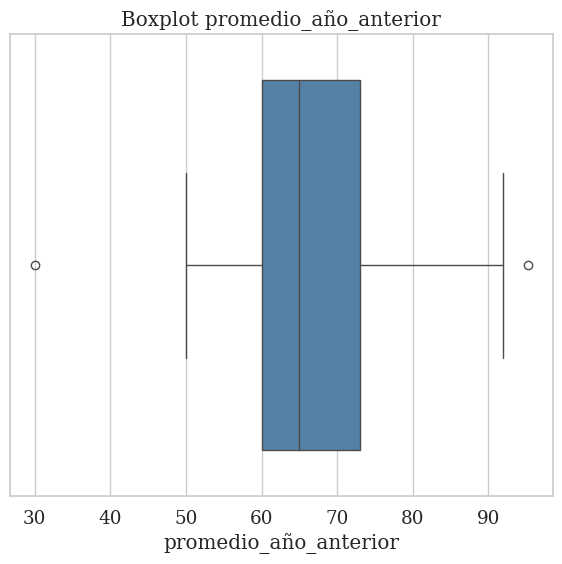

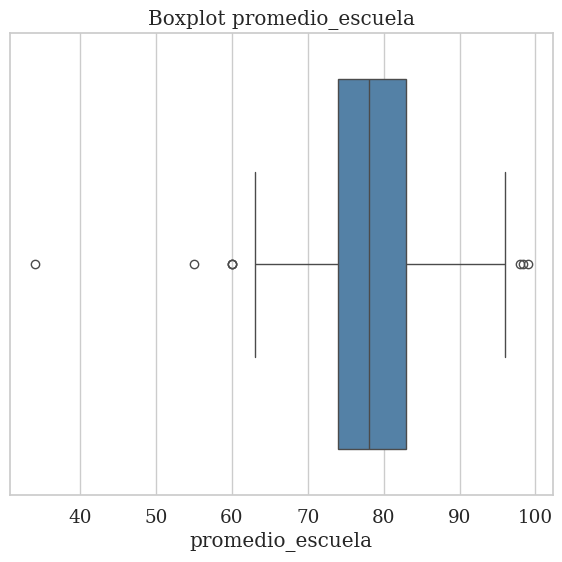

In [90]:
# diagrama de caja para las variables numericas

for var in variables_numericas:
    f, ax = plt.subplots(figsize=(7, 6))
    ax.set_title(f"Boxplot {var}")
    ax.set_ylabel("")
    
    sns.boxplot(
        x=df[var],      # uso explícito
        color="steelblue",  # en lugar de palette
        ax=ax
    )

plt.show()

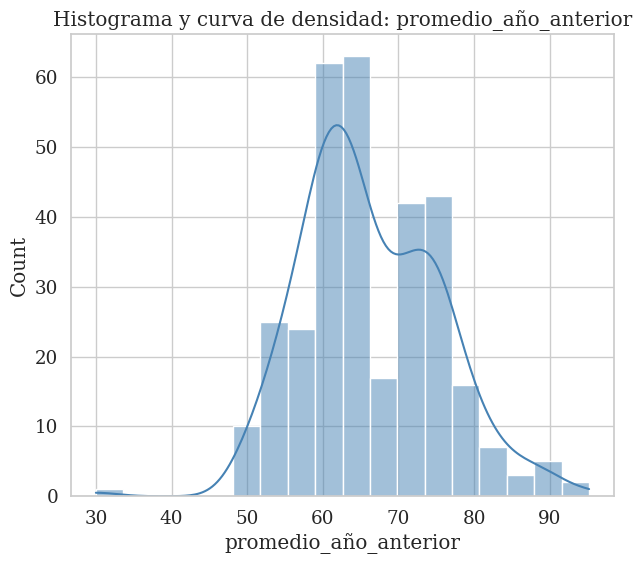

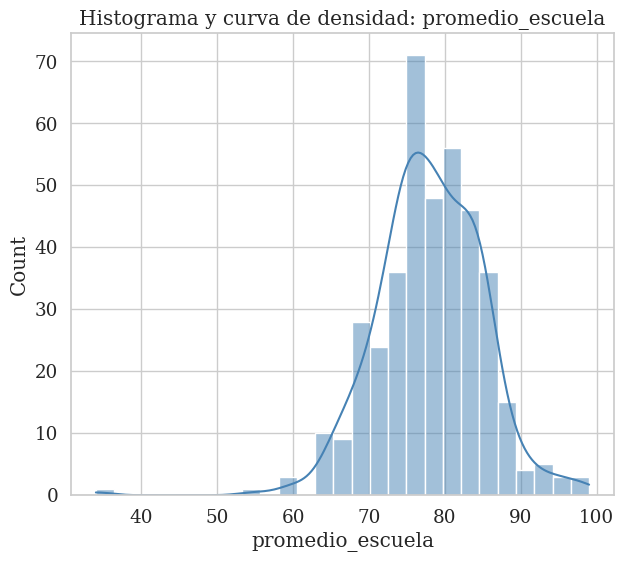

In [91]:
# Crear histogramas con curva de densidad, para cada variable numérica
for var in variables_numericas:
    f, ax = plt.subplots(figsize=(7, 6))
    ax.set_title(f"Histograma y curva de densidad: {var}")
    ax.set_xlabel(var)
    
    sns.histplot(
        x=df[var],      # uso explícito
        kde=True,
        color="steelblue",  # en lugar de palette
        ax=ax
    )

De los histogramas y sus curvas de densidad, podemos decir lo siguiente:

- Promedio año anterior (universitarios): La distribución se aproxima a una normal con centro alrededor de 63-65, aunque se observa una leve bimodalidad con un segundo pico cerca de 70-75, lo que podría indicar la existencia de dos subgrupos de rendimiento. Se presentan valores atípicos en ambas colas (por debajo de 40 y por encima de 90), pero con frecuencias despreciables. Este comportamiento es habitual en el contexto universitario.

- Promedio escuela: La distribución es aproximadamente normal con moda entre 75-80, pero presenta una asimetría negativa (sesgada a la izquierda), es decir, la mayoría de los estudiantes obtienen calificaciones altas mientras que la cola se extiende hacia valores bajos. Existen algunos casos atípicos con notas por debajo de 40 (reprobados), que representan una proporción pequeña del total. En el contexto escolar, este patrón es esperable, ya que las evaluaciones tienden a concentrar las calificaciones en rangos medios-altos.

### Tablas de frecuiencias para variables ordinales y nominales

In [92]:
# Crear función para tabla de frecuencias para variables categoricas
def tabla_frecuencias(df, variables_categoricas):
    for variable in variables_categoricas:
        conteo = df[variable].value_counts(dropna=True)
        porcentaje = round(df[variable].value_counts(normalize=True, dropna=True) * 100, 2)
        tabla = pd.DataFrame({variable: conteo.index, "Frecuencia": conteo.values, "Porcentaje (%)": porcentaje.values})

        display(tabla)
        print("\n")

In [93]:
var_cualitativas_nominales = ['genero','alojamiento_2023', 'beca',
                        'relacion_sentimental','aprobacion_padres_alcohol', "facultad"]

tabla_frecuencias(df, var_cualitativas_nominales)

,genero,Frecuencia,Porcentaje (%)
0,Male,216,53.47
1,Female,188,46.53


,alojamiento_2023,Frecuencia,Porcentaje (%)
0,privado,335,87.47
1,no privado,48,12.53


,beca,Frecuencia,Porcentaje (%)
0,No,352,88.44
1,Yes,46,11.56


,relacion_sentimental,Frecuencia,Porcentaje (%)
0,No,239,59.31
1,Yes,164,40.69


,aprobacion_padres_alcohol,Frecuencia,Porcentaje (%)
0,Yes,353,87.81
1,No,49,12.19


,facultad,Frecuencia,Porcentaje (%)
0,Economic & Management Sciences,211,52.88
1,Science,56,14.04
2,Arts & Social Sciences,47,11.78
3,Engineering,37,9.27
4,AgriSciences,22,5.51
5,Medicine and Health Services,10,2.51
6,Law,10,2.51
7,Education,6,1.50


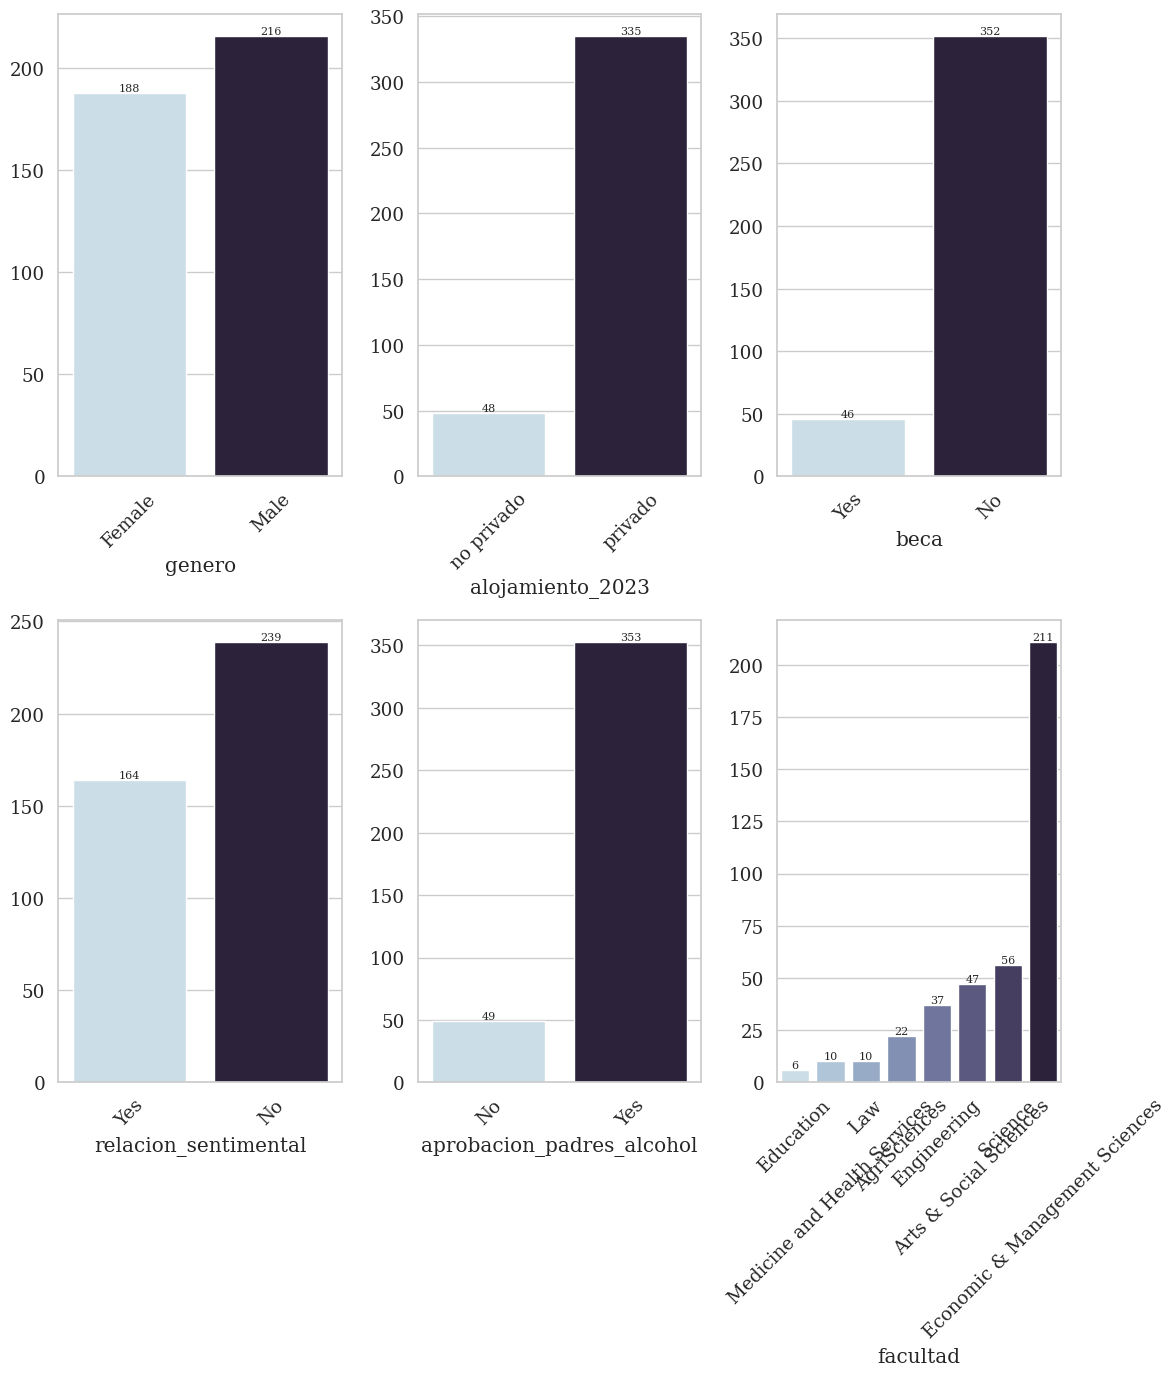

In [94]:
#digrama de barras para cada variable categorica
import math

n_vars = len(var_cualitativas_nominales)
n_cols = 3
n_rows = math.ceil(n_vars / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 7*n_rows))
axes = axes.flatten()  # para recorrer fácilmente


for i, var in enumerate(var_cualitativas_nominales):

    counts = df[var].value_counts().sort_values(ascending=True)

    ax = sns.barplot(
        x=counts.index,
        y=counts.values,
        hue=counts.index,
        palette="ch:s=.25,rot=-.25",
        legend=False,
        errorbar=None,
        ax=axes[i]
    )

    # Etiquetas encima
    for container in ax.containers:
        ax.bar_label(container, fontsize=8)

    ax.tick_params(axis='x', rotation=45)

# Eliminar ejes vacíos si sobran
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [95]:
var_cualitativas_ordinales = ['año_anterior', 'presupuesto',
                        'horas_estudio_semanal', 'fiestas_semanales',
                        'consumo_bebidas_alcoholicas', 'clases_perdidas(alcohol)',
                        'reprobaciones', 'tipo_relacion(padres)']

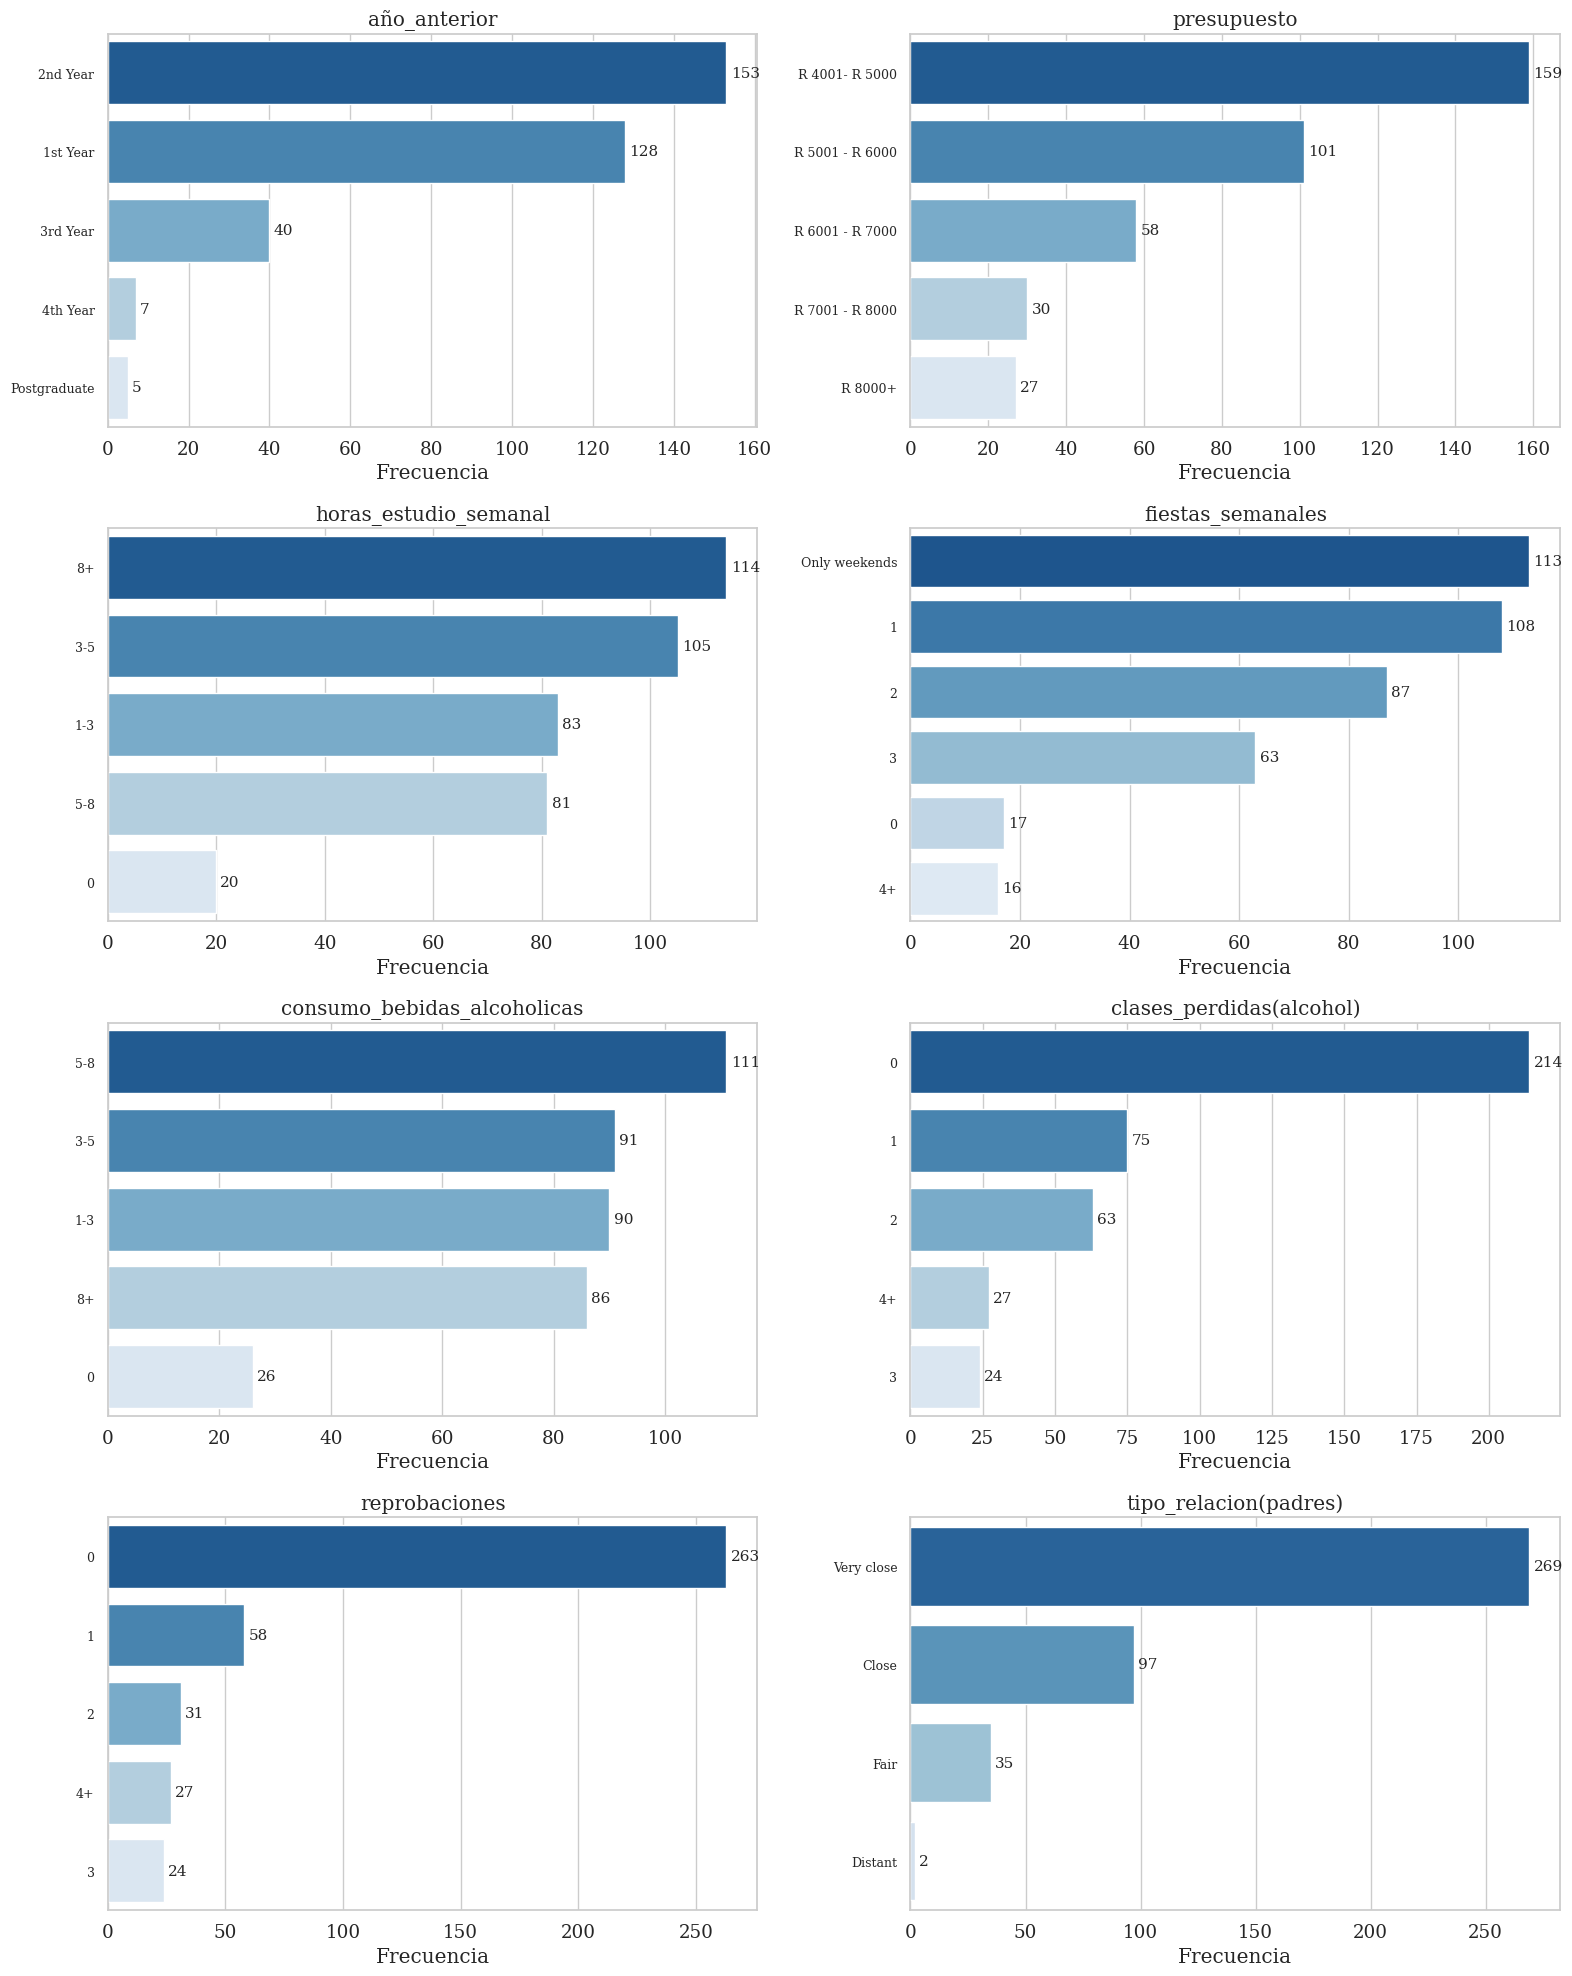

In [96]:
n_vars = len(var_cualitativas_ordinales)
n_cols = 2
n_rows = math.ceil(n_vars / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 5 * n_rows))
axes = axes.flatten()
# Generar paleta con tantos colores como categorías


for i, var in enumerate(var_cualitativas_ordinales):

    counts = df[var].value_counts().sort_values(ascending=False)

    ax = sns.barplot(
        x=counts.values,
        y=counts.index,
        hue=counts.index,      # ← necesario
        palette="Blues_r",
        legend=False,          # ← evita leyenda duplicada
        errorbar=None,
        ax=axes[i]
    )

    # Etiquetas al final de cada barra
    for container in ax.containers:
        ax.bar_label(container, fontsize=11, padding=3)

    ax.set_title(var)
    ax.set_xlabel("Frecuencia")
    ax.set_ylabel("")
    ax.tick_params(axis='y', labelsize=9)

# Eliminar ejes vacíos
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()